# 1.自行收集制作过去 1 年的比特币量价数据集，并根据该数据集预测未来 1 小时的币价（具体方法不限，要求逻辑严谨、步骤完备，需要给出完整代码）。

## 1.获取数据

In [45]:
#API受限无法获取min级别的数据只能使用hour级别的数据预测
import requests
import pandas as pd
import os
from datetime import datetime, timedelta


def get_btc_hourly(days=365):
    #计算时间范围
    end_ts = int(datetime.now().timestamp())
    start_ts = int((datetime.now() - timedelta(days=days)).timestamp())
    url = "https://min-api.cryptocompare.com/data/v2/histohour"
    all_data = []
    current_end = end_ts
    #分批拉取数据
    while current_end > start_ts:
        #计算还需要多少小时的数据
        remaining = int((current_end - start_ts) / 3600)
        limit = min(719, remaining) 
        params = {
            "fsym": "BTC",
            "tsym": "USD",
            "limit": limit,
            "toTs": current_end
        }
        try:
            #发起请求
            resp = requests.get(url, params=params)
            resp.raise_for_status()
            data = resp.json()
            if data["Response"] == "Success":
                batch = data["Data"]["Data"]
                all_data.extend(batch)
                if batch:
                    current_end = batch[0]["time"] - 3600  # 往前推1小时
                else:
                    break
                
                #进度提示
                print(f"累计获取 {len(all_data)} 条记录...")
            else:
                print(f"API出错: {data['Message']}")
                return None
                
        except Exception as e:
            print(f"请求失败: {e}")
            return None
    #处理数据
    if all_data:
        df = pd.DataFrame(all_data)
        df["timestamp"] = pd.to_datetime(df["time"], unit="s")
        #整理需要的列
        df = df[["timestamp", "open", "high", "low", "close", "volumefrom", "volumeto"]]
        df.columns = ["timestamp", "open", "high", "low", "close", "vol_from", "vol_to"]
        #按时间排序
        return df.sort_values("timestamp").reset_index(drop=True)
    else:
        print("没拿到任何数据")
        return None
def save_csv(df, folder="btc_data"):
    if not os.path.exists(folder):
        os.makedirs(folder)
    #生成文件名
    end_date = datetime.now().strftime("%Y%m%d")
    start_date = (datetime.now() - timedelta(days=365)).strftime("%Y%m%d")
    filename = f"btc_hourly_{start_date}-{end_date}.csv"
    filepath = os.path.join(folder, filename)
    df.to_csv(filepath, index=False)
    print(f"数据已存到: {filepath}")
if __name__ == "__main__":
    #拉取最近一年的数据
    btc_df = get_btc_hourly(days=365)
    #检查数据并保存
    if btc_df is not None and not btc_df.empty:
        save_csv(btc_df)
        print("\n前5条数据:")
        print(btc_df.head())
        print(f"\n时间范围: {btc_df['timestamp'].min()} 至 {btc_df['timestamp'].max()}")
        print(f"总记录数: {len(btc_df)}")
    else:
        print("获取数据失败")

已获取 720 条小时级数据...
已获取 1440 条小时级数据...
已获取 2160 条小时级数据...
已获取 2880 条小时级数据...
已获取 3600 条小时级数据...
已获取 4320 条小时级数据...
已获取 5040 条小时级数据...
已获取 5760 条小时级数据...
已获取 6480 条小时级数据...
已获取 7200 条小时级数据...
已获取 7920 条小时级数据...
已获取 8640 条小时级数据...
已获取 8760 条小时级数据...
数据已保存至: data\btc_usd_hourly_20240914_to_20250914.csv

数据预览:
            timestamp  open_price  high_price  low_price  close_price  \
0 2024-09-14 09:00:00    60002.10    60088.21   59892.88     60088.20   
1 2024-09-14 10:00:00    60088.20    60088.92   59819.81     59874.24   
2 2024-09-14 11:00:00    59874.24    59874.26   59628.10     59735.53   
3 2024-09-14 12:00:00    59735.53    59877.61   59661.27     59819.03   
4 2024-09-14 13:00:00    59819.03    59819.98   59671.82     59793.64   

   volume_from    volume_to  
0       306.62  18394724.34  
1       319.06  19125721.97  
2       488.92  29217036.26  
3       317.76  18998552.85  
4       341.99  20432650.88  

数据时间范围: 2024-09-14 09:00:00 至 2025-09-14 08:00:00
总记录数: 8760


## 2.读取数据

In [1]:
import pandas as pd
#读取CSV文件
data = pd.read_csv('./data/btc_usd_hourly_20240914_to_20250914.csv')
# 将timestamp转换为日期时间格式
data['timestamp'] = pd.to_datetime(data['timestamp'])
#索引
data.set_index('timestamp', inplace=True)
print(f"数据时间范围: {data.index.min()} 至 {data.index.max()}")
print(f"数据记录数: {len(data)}")
print("\n数据前5行:")
display(data.head())

数据时间范围: 2024-09-14 11:00:00 至 2025-09-14 10:00:00
数据记录数: 8760

数据前5行:


,open_price,high_price,low_price,close_price,volume_from,volume_to
timestamp,,,,,,
2024-09-14 11:00:00,59874.24,59874.26,59628.10,59735.53,488.92,29217036.26
2024-09-14 12:00:00,59735.53,59877.61,59661.27,59819.03,317.76,18998552.85
2024-09-14 13:00:00,59819.03,59819.98,59671.82,59793.64,341.99,20432650.88
2024-09-14 14:00:00,59793.64,60034.64,59728.01,59936.82,538.09,32240604.69
2024-09-14 15:00:00,59936.82,59967.60,59845.58,59896.66,362.74,21734394.27


## 3.数据清洗预处理

In [2]:
#检查数据完整性
print("数据完整性检查:")
print(data.isnull().sum())
if data.isnull().any().any():
    print("\n发现缺失值，进行填充处理...")
    data = data.ffill()  

数据完整性检查:
open_price     0
high_price     0
low_price      0
close_price    0
volume_from    0
volume_to      0
dtype: int64


## 4.可视化

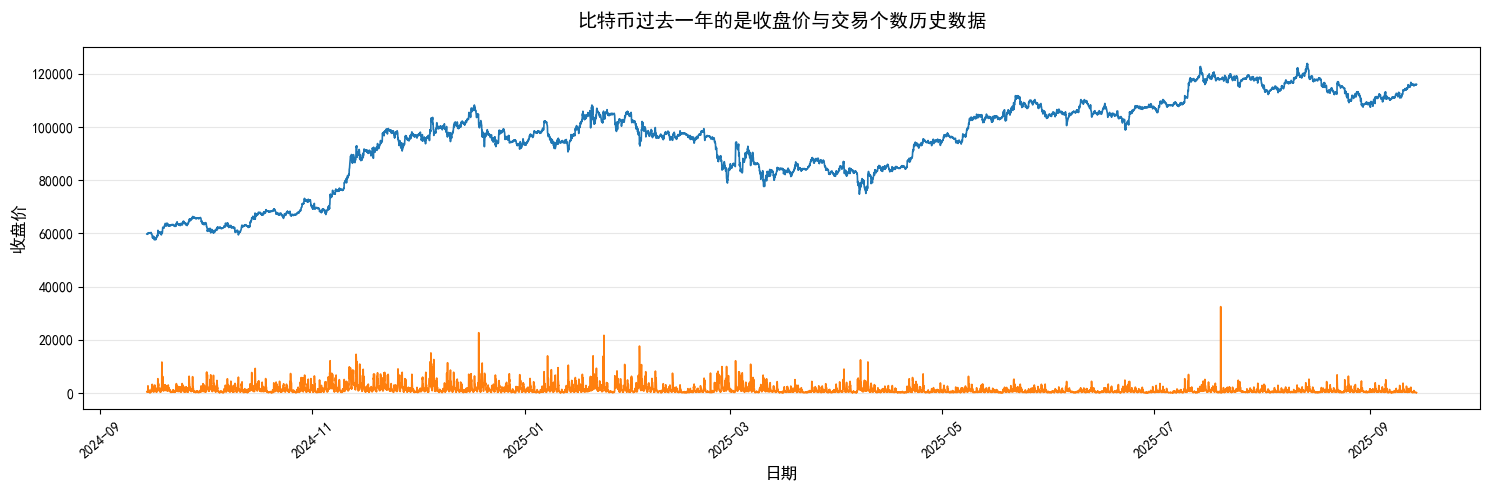

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['font.family'] = ['SimHei']  
plt.figure(figsize=(15, 5)) 
plt.plot(
    data.index,  
    data['close_price'],  
    data['volume_from'],  
    linewidth=1.2  
)
plt.title('比特币过去一年的是收盘价与交易个数历史数据', fontsize=14, pad=15)  
plt.ylabel('收盘价', fontsize=12)  
plt.xlabel('日期', fontsize=12)  
plt.xticks(rotation=40, fontsize=10)  
plt.grid(axis='y', alpha=0.3)  
plt.tight_layout()  
plt.show()

## 预测未来比特币价格

### 方法1:ARMA模型

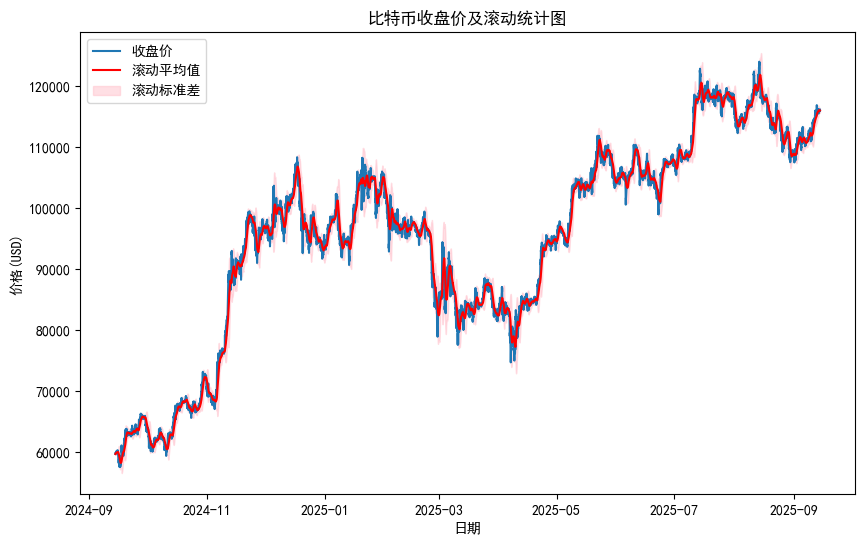

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm 
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
df = pd.DataFrame(data['close_price'])
#计算收盘价的滚动平均值和滚动标准差
rolling_mean = df['close_price'].rolling(window=30,min_periods=1).mean()
rolling_std = df['close_price'].rolling(window=30,min_periods=1).std()
#绘制收盘的折线图和滚动平均值和滚动标准差的线图
plt.figure(figsize=(10,6))
plt.plot(df['close_price'],label='收盘价')
plt.plot(rolling_mean,label='滚动平均值',color='red')
plt.fill_between(rolling_std.index,rolling_mean-2 * rolling_std,rolling_mean
                + 2 * rolling_std,color='pink',alpha=0.5,label='滚动标准差')
plt.xlabel('日期')
plt.ylabel('价格(USD)')
plt.title('比特币收盘价及滚动统计图')
plt.legend()
plt.show()

In [5]:
model = sm.tsa.ARIMA(df['close_price'],order=(1,2,1))
results = model.fit()
#打印结果
print(results.summary())

D:\anaconda\envs\financial-ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
D:\anaconda\envs\financial-ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
D:\anaconda\envs\financial-ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            close_price   No. Observations:                 8760
Model:                 ARIMA(1, 2, 1)   Log Likelihood              -66353.693
Date:                Mon, 15 Sep 2025   AIC                         132713.386
Time:                        10:16:47   BIC                         132734.620
Sample:                    09-14-2024   HQIC                        132720.621
                         - 09-14-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0162      0.003      4.835      0.000       0.010       0.023
ma.L1         -1.0000      0.002   -524.797      0.000      -1.004      -0.996
sigma2      2.097e+05   1270.347    165.040      0.0

C:\Users\86157\AppData\Local\Temp\ipykernel_29396\1897431787.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast_price = results.predict(start=len(df), end=len(df))[0]


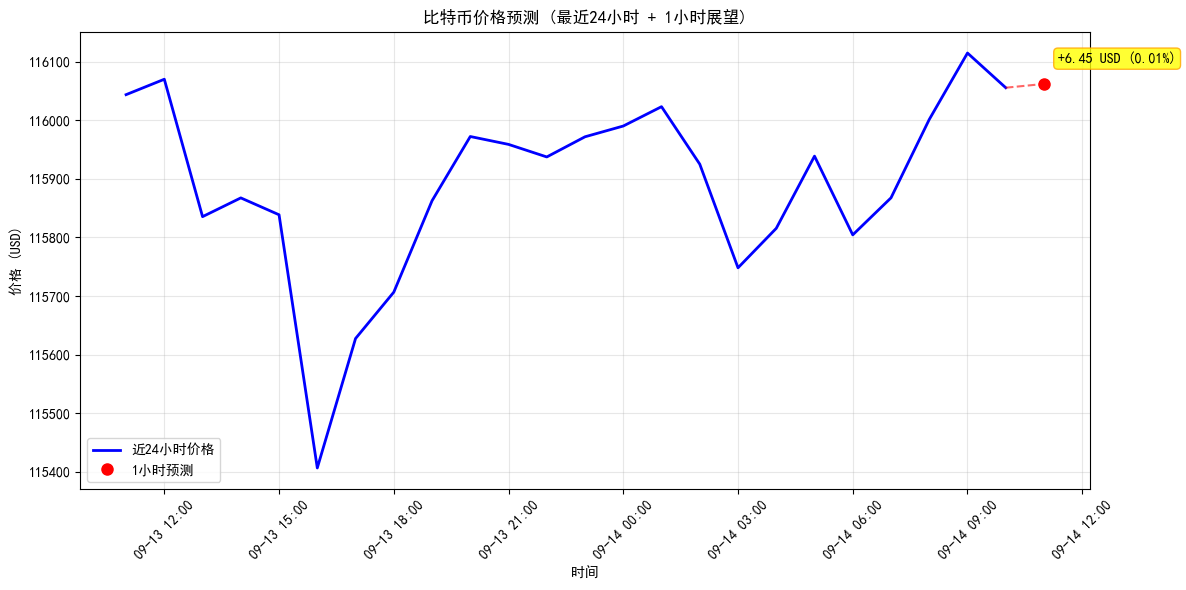

最后记录: 2025-09-14 10:00:00 | 价格: 116055.73 USD
预测时间: 2025-09-14 11:00:00 | 价格: 116062.18 USD
趋势: 上涨
变动: 6.45 USD (0.01%)


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
import numpy as np
def plot_forecast(df, results, price_col='close_price'):
    #提取关键时间点和价格
    last_time = df.index[-1]
    last_price = df[price_col].iloc[-1]
    #预测未来1小时
    forecast_time = last_time + timedelta(hours=1)
    forecast_price = results.predict(start=len(df), end=len(df))[0]
    #计算涨跌幅
    change = forecast_price - last_price
    change_pct = (change / last_price) * 100
    #准备绘图数据
    recent = df[[price_col]].tail(24)
    forecast_series = pd.Series([forecast_price], index=[forecast_time])
    #绘图设置
    plt.figure(figsize=(12, 6))
    ax = plt.gca()
    #绘制历史与预测曲线
    ax.plot(recent.index, recent[price_col], 'b-', lw=2, label='近24小时价格')
    ax.plot(forecast_series.index, forecast_series.values, 'ro', ms=8, label=f'1小时预测')
    ax.plot([last_time, forecast_time], [last_price, forecast_price], 'r--', alpha=0.6)
    #标注涨跌幅
    label_pos = (10, 15) if change >= 0 else (10, -30)
    ax.annotate(
        f'{"+" if change>0 else ""}{change:.2f} USD ({change_pct:.2f}%)',
        xy=(forecast_time, forecast_price),
        xytext=label_pos,
        textcoords='offset points',
        bbox=dict(boxstyle='round', fc='yellow', ec='orange', alpha=0.8)
    )
    #时间轴格式化
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)
    #图表基础设置
    ax.set(title='比特币价格预测 (最近24小时 + 1小时展望)',
           xlabel='时间', ylabel=f'价格 (USD)')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    #打印结果
    print(f"最后记录: {last_time} | 价格: {last_price:.2f} USD")
    print(f"预测时间: {forecast_time} | 价格: {forecast_price:.2f} USD")
    print(f"趋势: {'上涨' if change>0 else '下跌' if change<0 else '持平'}")
    print(f"变动: {change:.2f} USD ({change_pct:.2f}%)")
plot_forecast(df, results)

 ### 方法二:LSTM时间序列预测模型

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
import tensorflow as tf
import os
from pathlib import Path
#设置中文显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False  
#设置随机种子
np.random.seed(42)
tf.random.set_seed(42)
#加载本地数据
data_path = Path("data") / "btc_usd_hourly_20240914_to_20250914.csv"
df = pd.read_csv(data_path,parse_dates=['timestamp'],index_col='timestamp')  
#显示基本信息
print(f"数据时间范围: {df.index.min()} 至 {df.index.max()}")
print(f"数据记录数: {len(df)}")
print("\n数据前5行:")
display(df.head())

数据时间范围: 2024-09-14 09:00:00 至 2025-09-14 08:00:00
数据记录数: 8760

数据前5行:


,open_price,high_price,low_price,close_price,volume_from,volume_to
timestamp,,,,,,
2024-09-14 09:00:00,60002.10,60088.21,59892.88,60088.20,306.62,18394724.34
2024-09-14 10:00:00,60088.20,60088.92,59819.81,59874.24,319.06,19125721.97
2024-09-14 11:00:00,59874.24,59874.26,59628.10,59735.53,488.92,29217036.26
2024-09-14 12:00:00,59735.53,59877.61,59661.27,59819.03,317.76,18998552.85
2024-09-14 13:00:00,59819.03,59819.98,59671.82,59793.64,341.99,20432650.88


In [42]:
#数据预处理与探索性分析 - 缺失值检查# 检查数据完整性
print("数据完整性检查:")
print(df.isnull().sum())
if df.isnull().any().any():
    print("\n发现缺失值，进行填充处理...")
    df = df.ffill()  

数据完整性检查:
open_price     0
high_price     0
low_price      0
close_price    0
volume_from    0
volume_to      0
dtype: int64


In [43]:
#查看数据统计信息
print("数据统计摘要:")
display(df.describe())

数据统计摘要:


,open_price,high_price,low_price,close_price,volume_from,volume_to
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8.760000e+03
mean,95125.541764,95424.247400,94826.504313,95131.925623,1279.371768,1.183576e+08
std,16191.488694,16203.415497,16174.310108,16188.667607,1592.734148,1.493691e+08
min,57595.260000,57945.830000,57486.820000,57595.260000,35.280000,3.701554e+06
25%,84608.067500,84891.905000,84370.617500,84612.595000,378.705000,3.607886e+07
50%,97184.290000,97507.345000,96872.475000,97186.185000,717.800000,6.721097e+07
75%,107135.287500,107375.302500,106847.162500,107136.950000,1534.140000,1.419071e+08
max,123901.800000,124532.700000,123400.200000,123901.800000,32449.450000,3.829935e+09


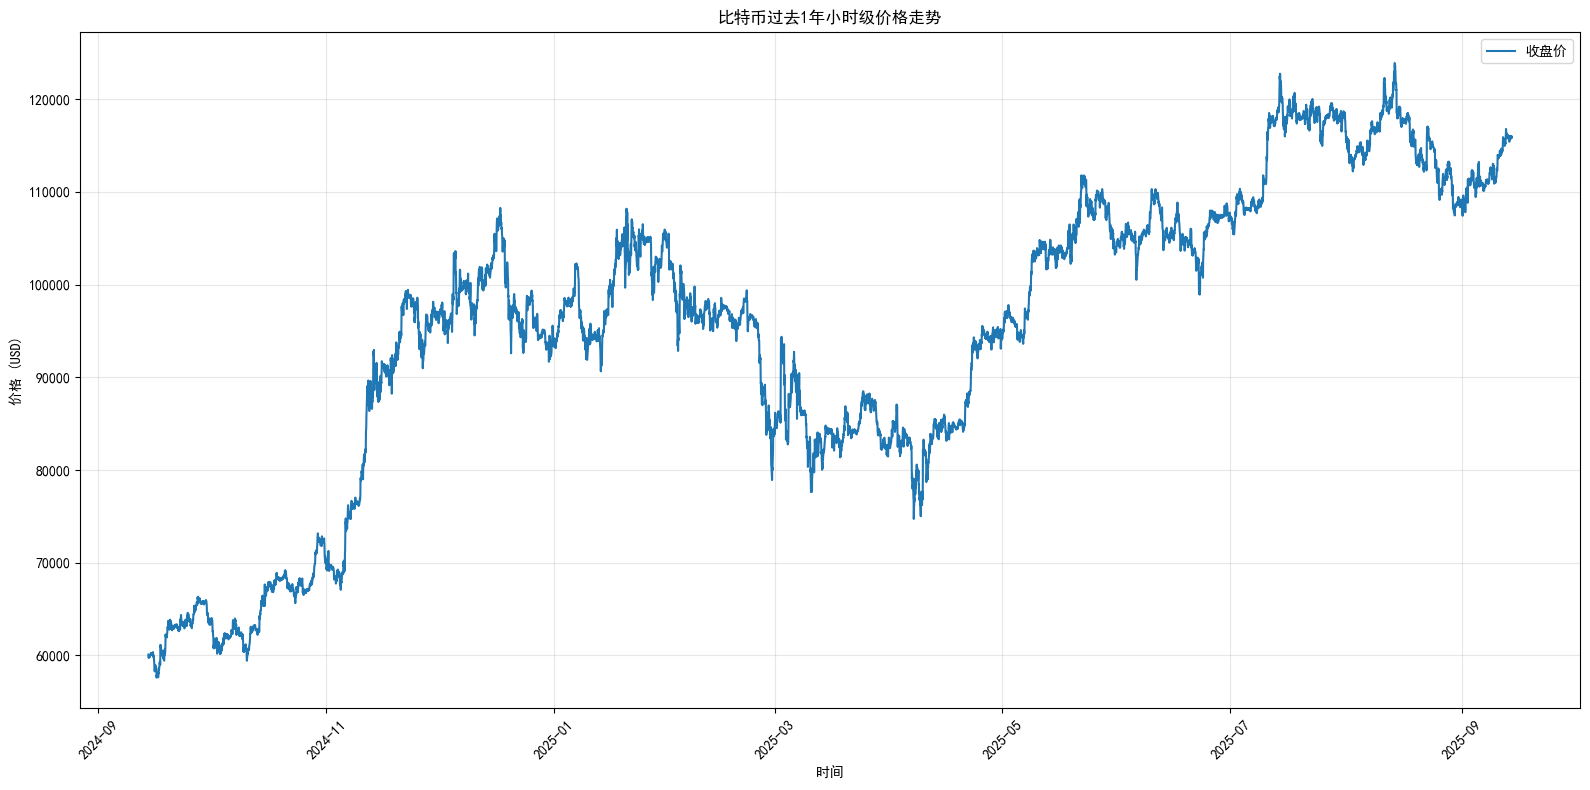

In [44]:
#绘制价格走势
plt.figure(figsize=(16, 8))
plt.plot(df.index, df['close_price'], label='收盘价', linewidth=1.5)
plt.title('比特币过去1年小时级价格走势')
plt.xlabel('时间')
plt.ylabel('价格 (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

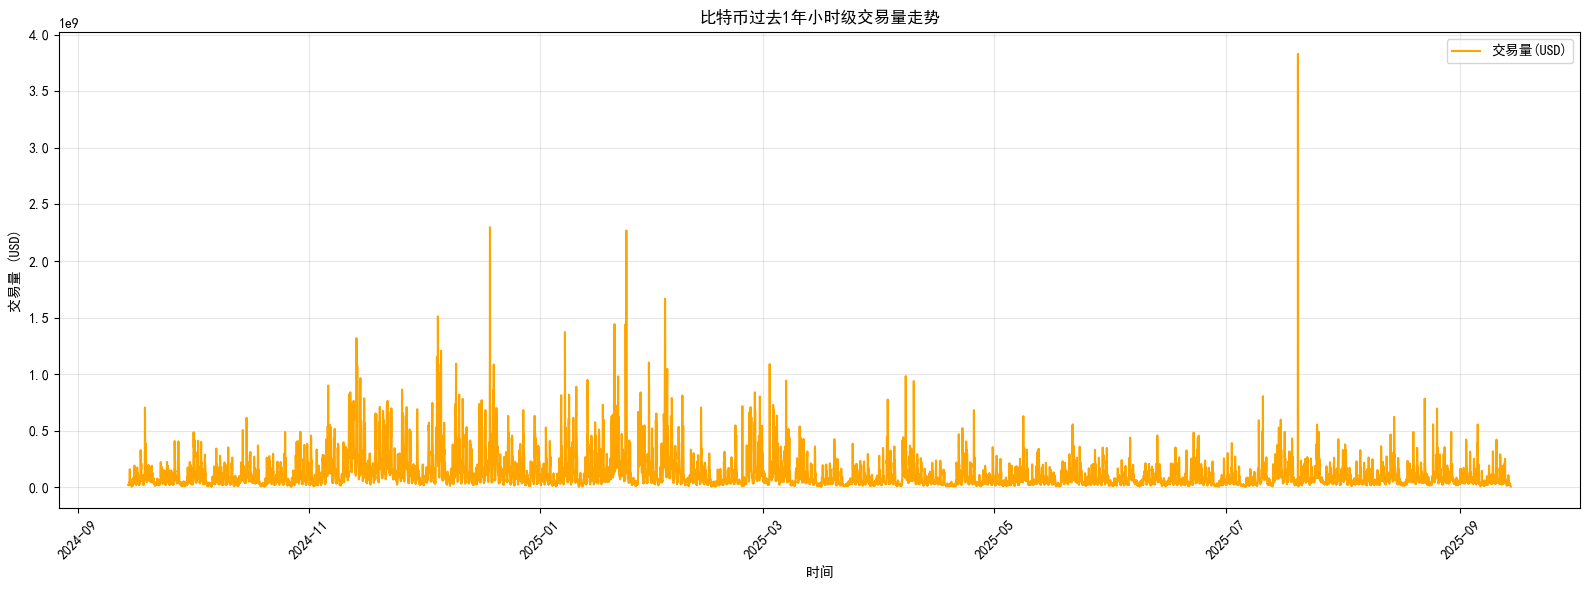

In [45]:
#绘制交易量走势
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['volume_to'], label='交易量(USD)', color='orange')
plt.title('比特币过去1年小时级交易量走势')
plt.xlabel('时间')
plt.ylabel('交易量 (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

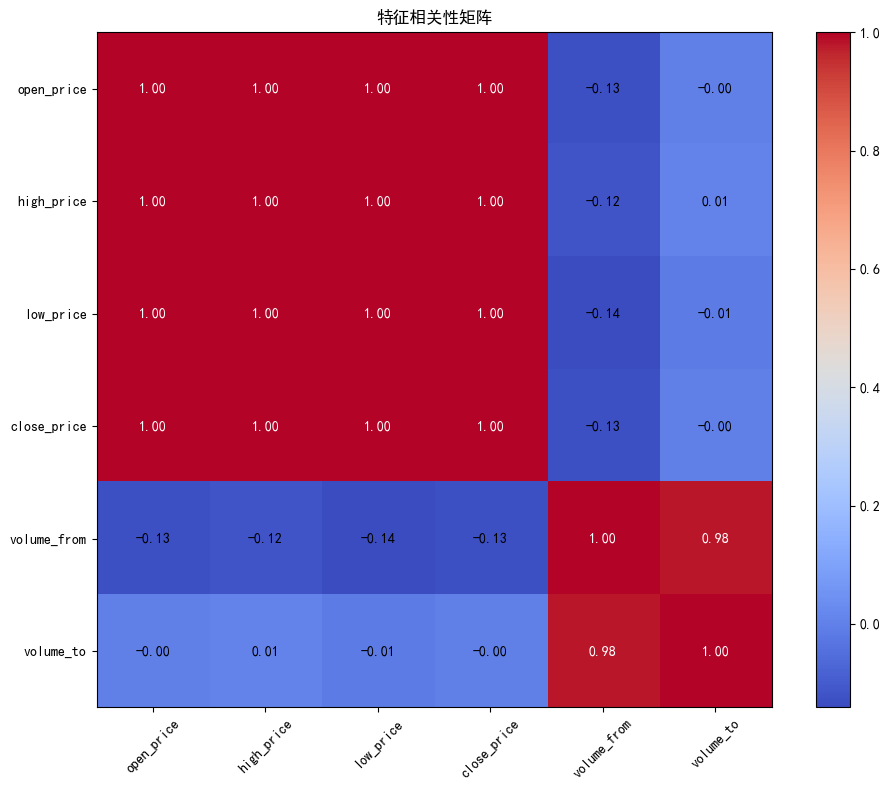

In [46]:
#检查相关性
plt.figure(figsize=(10, 8))
correlation = df.corr()
plt.imshow(correlation, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation)), correlation.columns)
plt.title('特征相关性矩阵')
for i in range(correlation.shape[0]):
    for j in range(correlation.shape[1]):
        plt.text(j, i, f"{correlation.iloc[i, j]:.2f}", 
                 horizontalalignment="center", 
                 verticalalignment="center",
                 color="white" if abs(correlation.iloc[i, j]) > 0.5 else "black")
plt.tight_layout()
plt.show()

In [47]:
#创建技术指标特征，增强模型预测能力
df['price_change'] = df['close_price'].pct_change() 
df['high_low_range'] = df['high_price'] - df['low_price']  
df['high_low_ratio'] = df['high_low_range'] / df['close_price']  
#创建移动平均线特征
df['ma5'] = df['close_price'].rolling(window=5).mean() 
df['ma20'] = df['close_price'].rolling(window=20).mean()  
df['ma50'] = df['close_price'].rolling(window=50).mean()  
# 创建交易量变化特征
df['volume_change'] = df['volume_to'].pct_change() 
#去除包含NaN值的行
df = df.dropna()
#显示处理后的特征
print("处理后的特征数据:")
display(df.head())

处理后的特征数据:


,open_price,high_price,low_price,close_price,volume_from,volume_to,price_change,high_low_range,high_low_ratio,ma5,ma20,ma50,volume_change
timestamp,,,,,,,,,,,,,
2024-09-16 10:00:00,58639.65,58741.76,58504.95,58741.76,565.10,3.311753e+07,0.001741,236.81,0.004031,58783.730,59157.4710,59683.7508,-0.154407
2024-09-16 11:00:00,58741.76,58839.99,58652.88,58663.18,326.75,1.919562e+07,-0.001338,187.11,0.003190,58774.732,59072.9535,59655.2504,-0.420379
2024-09-16 12:00:00,58663.18,58789.51,58445.29,58529.42,760.53,4.456781e+07,-0.002280,344.22,0.005881,58699.094,59000.9125,59628.3540,1.321770
2024-09-16 13:00:00,58529.42,58610.48,58022.92,58491.75,1854.67,1.081964e+08,-0.000644,587.56,0.010045,58613.152,58933.6200,59603.4784,1.427680
2024-09-16 14:00:00,58491.75,58553.29,57560.73,57595.26,2612.89,1.513105e+08,-0.015327,992.56,0.017233,58404.274,58813.9500,59559.0030,0.398480


In [48]:
#数据准备与划分
features = [
    'open_price', 'high_price', 'low_price', 'close_price',
    'volume_from', 'volume_to', 'price_change', 
    'high_low_range', 'high_low_ratio', 'ma5', 'ma20', 'ma50',
    'volume_change'
]
#提取特征数据
data = df[features].values
#数据归一化
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
#设置时间窗口参数
window_size = 24 
#创建训练数据
X, y = [], []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, :])
    #预测下一小时的收盘价
    y.append(scaled_data[i, 3])  
X, y = np.array(X), np.array(y)
#划分训练集和测试集
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
#调整输入形状
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")
print(f"输入特征数: {X_train.shape[2]}")
print(f"时间窗口大小: {window_size}")

训练集大小: 6949
测试集大小: 1738
输入特征数: 13
时间窗口大小: 24


In [49]:
#构建ISTM模型
model = Sequential([
    #双向LSTM层
    Bidirectional(LSTM(units=64, return_sequences=True), 
                  input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    #第二双向LSTM层
    Bidirectional(LSTM(units=32)),
    Dropout(0.2),
    #全连接层
    Dense(units=16, activation='relu'),
    #输出层，预测收盘价
    Dense(units=1)
])
#编译模型
model.compile(optimizer='adam', loss='mean_squared_error')
#查看模型结构
print("模型结构:")
model.summary()

模型结构:


C:\Users\86157\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 24, 128)        │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,209 (321.13 KB)

 Trainable params: 82,209 (321.13 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
#设置训练参数
epochs = 50
batch_size = 32
#训练模型
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0096 - val_loss: 0.0035
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0018 - val_loss: 3.9456e-04
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0015 - val_loss: 0.0028
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 5/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0010 - val_loss: 2.7042e-04
Epoch 6/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 8.9201e-04 - val_loss: 0.0013
Epoch 7/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 7.5701e-04 - val_loss: 4.8162e-04
Epoch 8/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 6.6179e-04 - val_loss: 7.8315e-04
Epoch 9/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 5.7049e-04 - val_loss: 1.8795e-04
Epoch 10/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 4.6667e-04 - val_loss: 4.1166e-04
Epoch 11/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 4.3201e-04 - val_loss: 

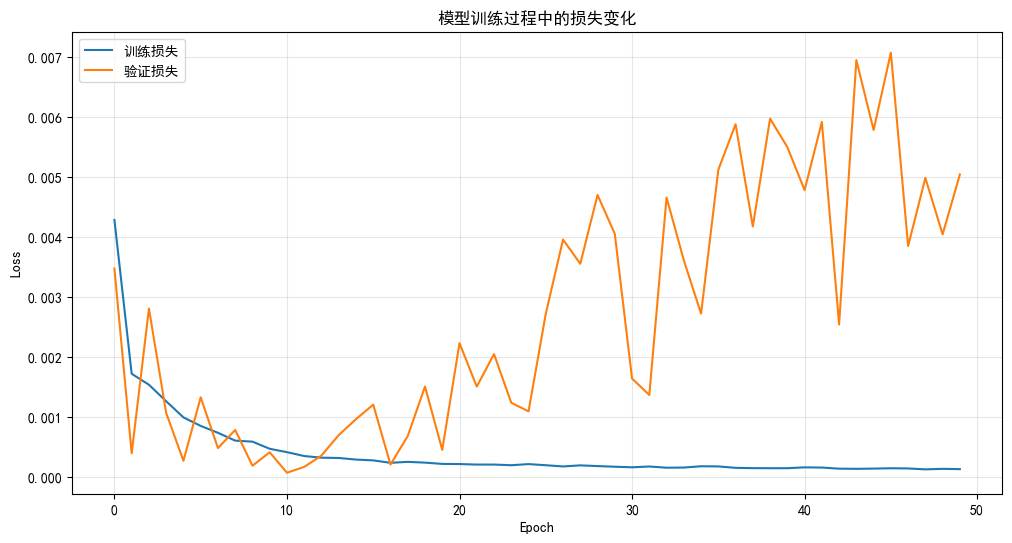

In [51]:
#模型训练过程可视化
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.title('模型训练过程中的损失变化')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [52]:
#模型预测与评估
predictions = model.predict(X_test)
#反归一化预测结果
#创建一个与scaler期望形状相同的数组
dummy = np.zeros((len(predictions), len(features)))
dummy[:, 3] = predictions.flatten()  
predictions = scaler.inverse_transform(dummy)[:, 3]  
#反归一化实际值
dummy = np.zeros((len(y_test), len(features)))
dummy[:, 3] = y_test
y_test_actual = scaler.inverse_transform(dummy)[:, 3]
#计算评估指标
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions)
mape = mean_absolute_percentage_error(y_test_actual, predictions) * 100
print("模型评估指标:")
print(f"均方误差 (MSE): {mse:.2f}")
print(f"均方根误差 (RMSE): {rmse:.2f} 美元")
print(f"平均绝对误差 (MAE): {mae:.2f} 美元")
print(f"平均绝对百分比误差 (MAPE): {mape:.2f}%")

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
模型评估指标:
均方误差 (MSE): 22162214.81
均方根误差 (RMSE): 4707.68 美元
平均绝对误差 (MAE): 4638.12 美元
平均绝对百分比误差 (MAPE): 4.02%


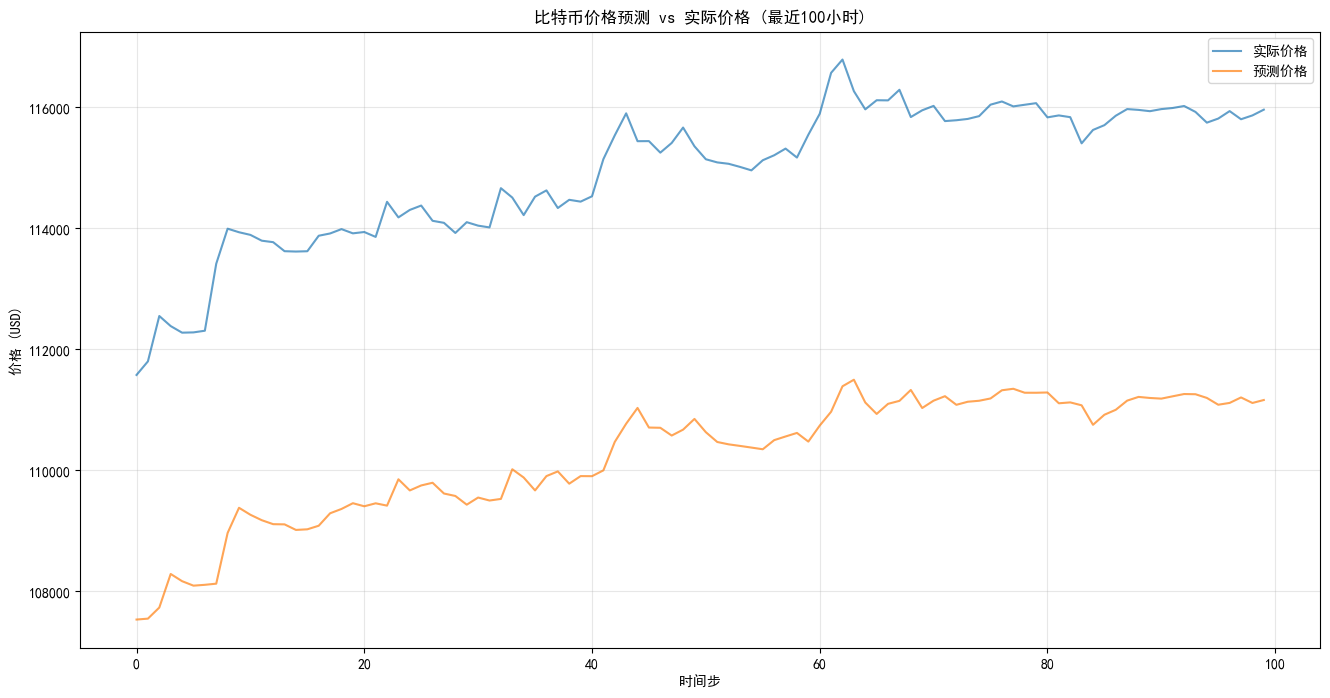

In [53]:
##预测结果可视化
plot_samples = 100  
plt.figure(figsize=(16, 8))
plt.plot(y_test_actual[-plot_samples:], label='实际价格', alpha=0.7)
plt.plot(predictions[-plot_samples:], label='预测价格', alpha=0.7)
plt.title(f'比特币价格预测 vs 实际价格 (最近{plot_samples}小时)')
plt.xlabel('时间步')
plt.ylabel('价格 (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

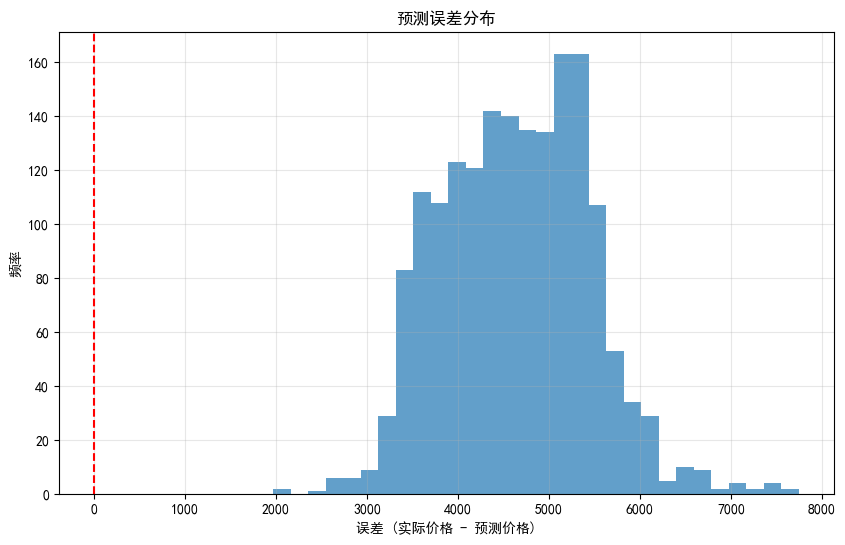

In [54]:
#绘制预测误差分布
errors = y_test_actual - predictions
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('预测误差分布')
plt.xlabel('误差 (实际价格 - 预测价格)')
plt.ylabel('频率')
plt.grid(alpha=0.3)
plt.show()

In [55]:
#预测未来1小时价格
#获取最近的window_size小时数据
last_sequence = scaled_data[-window_size:]
last_sequence = np.reshape(last_sequence, (1, window_size, len(features)))
#预测未来1小时价格
next_hour_pred = model.predict(last_sequence)[0, 0]
#反归一化预测结果
dummy = np.zeros((1, len(features)))
dummy[0, 3] = next_hour_pred
next_hour_price = scaler.inverse_transform(dummy)[0, 3]
#计算预测时间点
last_time = df.index[-1]
next_hour_time = last_time + timedelta(hours=1)
#显示预测结果
print("未来1小时比特币价格预测:")
print(f"预测时间点: {next_hour_time}")
print(f"预测价格: {next_hour_price:.2f} 美元")
print(f"最后已知价格 ({last_time}): {df['close_price'].iloc[-1]:.2f} 美元")
print(f"预测变化: {'上涨' if next_hour_price > df['close_price'].iloc[-1] else '下跌'} "
      f"{abs(next_hour_price - df['close_price'].iloc[-1]):.2f} 美元 "
      f"({abs(next_hour_price - df['close_price'].iloc[-1])/df['close_price'].iloc[-1]*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
未来1小时比特币价格预测:
预测时间点: 2025-09-14 09:00:00
预测价格: 111235.62 美元
最后已知价格 (2025-09-14 08:00:00): 115962.79 美元
预测变化: 下跌 4727.17 美元 (4.08%)


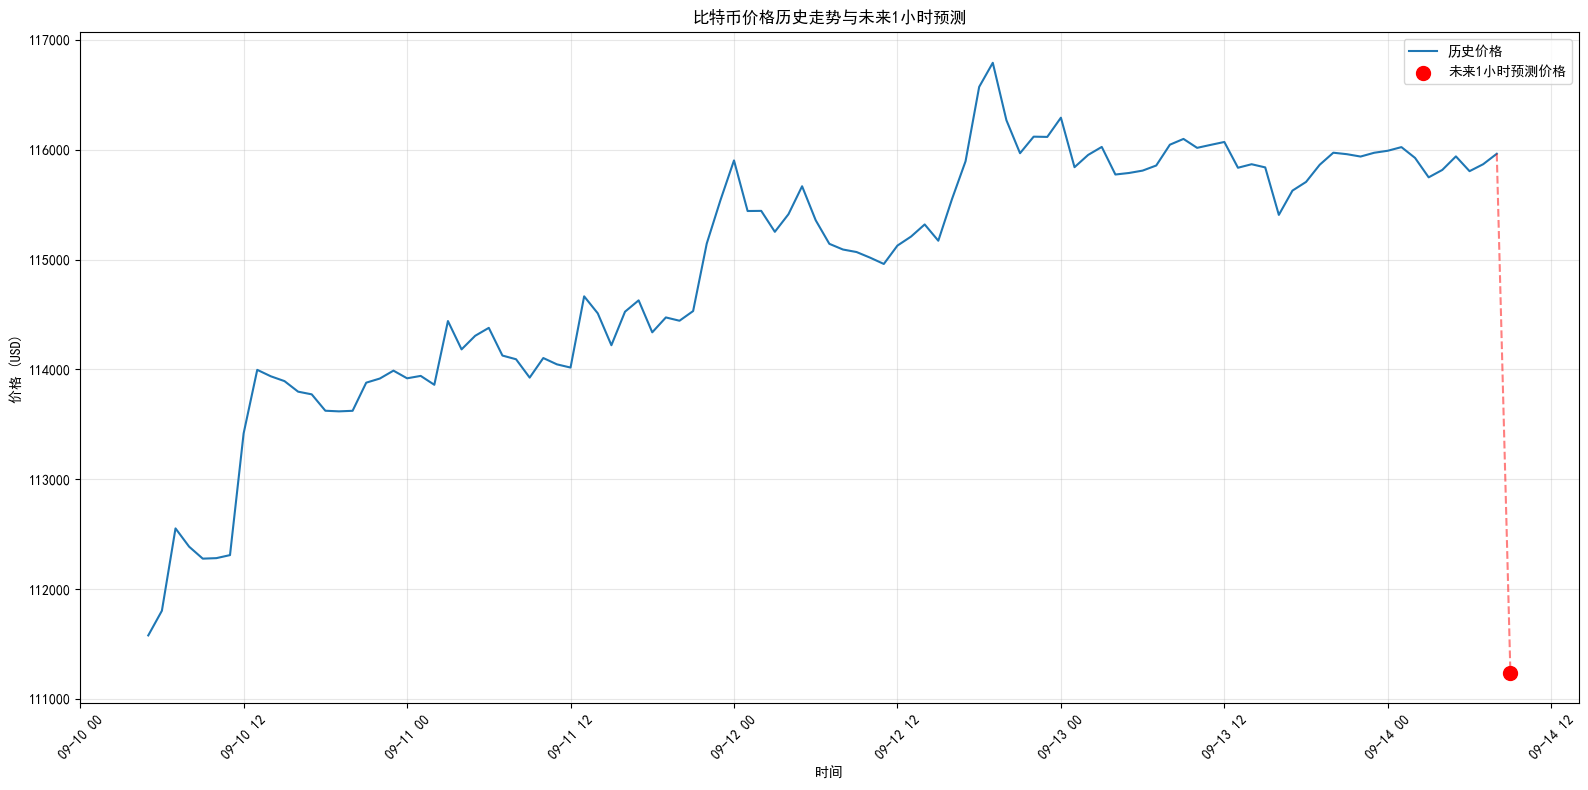

In [56]:
#预测结果可视化
plt.figure(figsize=(16, 8))
#绘制最近100小时的历史数据
plt.plot(df.index[-100:], df['close_price'].iloc[-100:], label='历史价格')
#绘制预测点
plt.scatter([next_hour_time], [next_hour_price], color='red', s=100, label='未来1小时预测价格', zorder=5)
#连接线，显示趋势
plt.plot([df.index[-1], next_hour_time], [df['close_price'].iloc[-1], next_hour_price], 
         'r--', alpha=0.5)
plt.title('比特币价格历史走势与未来1小时预测')
plt.xlabel('时间')
plt.ylabel('价格 (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()